In [73]:
from tsai.all import *
my_setup()

os              : Windows-10-10.0.26200-SP0
python          : 3.10.0
tsai            : 0.4.0
fastai          : 2.7.19
fastcore        : 1.7.29
torch           : 2.5.1+cpu
device          : cpu
cpu cores       : 6
threads per cpu : 2
RAM             : 15.86 GB
GPU memory      : [6.0] GB


In [74]:
##### TUTORIAL #####
dsid = 'AppliancesEnergy' 
X, y, splits = get_regression_data(dsid, split_data=False)
X.shape, y.shape, y[:10]

((137, 24, 144),
 (137,),
 memmap([19.38, 12.68,  5.34, 12.72, 13.25, 26.28, 13.1 , 14.06, 10.92,
         10.46]))

X      - shape: [137 samples x 24 features x 144 timesteps]  type: memmap  dtype:float64  isnan: 0
y      - shape: (137,)  type: memmap  dtype:float64  isnan: 0
splits - n_splits: 2 shape: [95, 42]  overlap: False


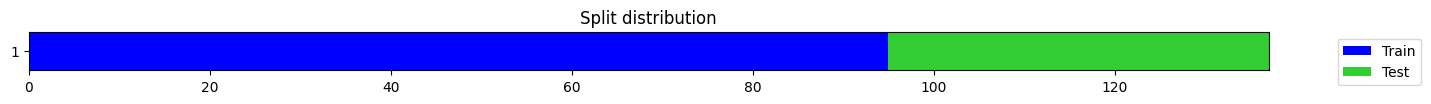

In [75]:
##### TUTORIAL #####
check_data(X, y, splits)

In [76]:
##### TUTORIAL #####
tfms  = [None, [TSRegression()]]
batch_tfms = TSStandardize(by_sample=True, by_var=True)
dls = get_ts_dls(X, y, splits=splits, tfms=tfms, batch_tfms=batch_tfms, bs=128)
dls.one_batch()

(TSTensor(samples:95, vars:24, len:144, device=cpu, dtype=torch.float32),
 tensor([ 9.8200, 14.0600, 12.9800,  9.6300, 14.2800, 14.9900, 10.8200, 23.4200,
         13.3700, 11.9200, 19.3800, 17.0000, 12.6800, 11.8300, 11.0600, 21.4900,
         15.6800, 21.7400, 16.2500, 10.1700, 11.4900, 18.5600, 23.0100, 10.8000,
         21.3100, 13.2900, 14.7100, 12.9700, 16.2200, 15.8900, 12.7200, 19.0100,
         11.5400,  7.0300, 21.6900,  5.3400, 17.6600, 19.6200, 10.4600,  8.7500,
         16.0500, 12.5400, 16.0200, 13.5600, 19.2200, 11.5300, 19.9400, 11.9300,
         22.7400, 11.6300,  9.1700, 10.6100, 13.6900, 20.4400, 26.2800, 10.8900,
         12.0300,  5.3800, 10.9200, 10.2600, 14.8200, 13.2500, 20.7400, 21.9100,
         16.4100, 13.8700, 17.3000, 16.5300, 14.6100, 18.1800, 13.2100, 14.6200,
          9.9900, 10.6300, 14.8000, 11.3200, 12.2400, 17.5300, 12.0700, 10.1100,
         11.4000, 11.2300, 10.5100,  8.6200, 12.6800, 10.3100, 12.7800, 16.7700,
          9.6000, 13.1000, 10.5100,

In [77]:
##### TUTORIAL #####
dls.c

1

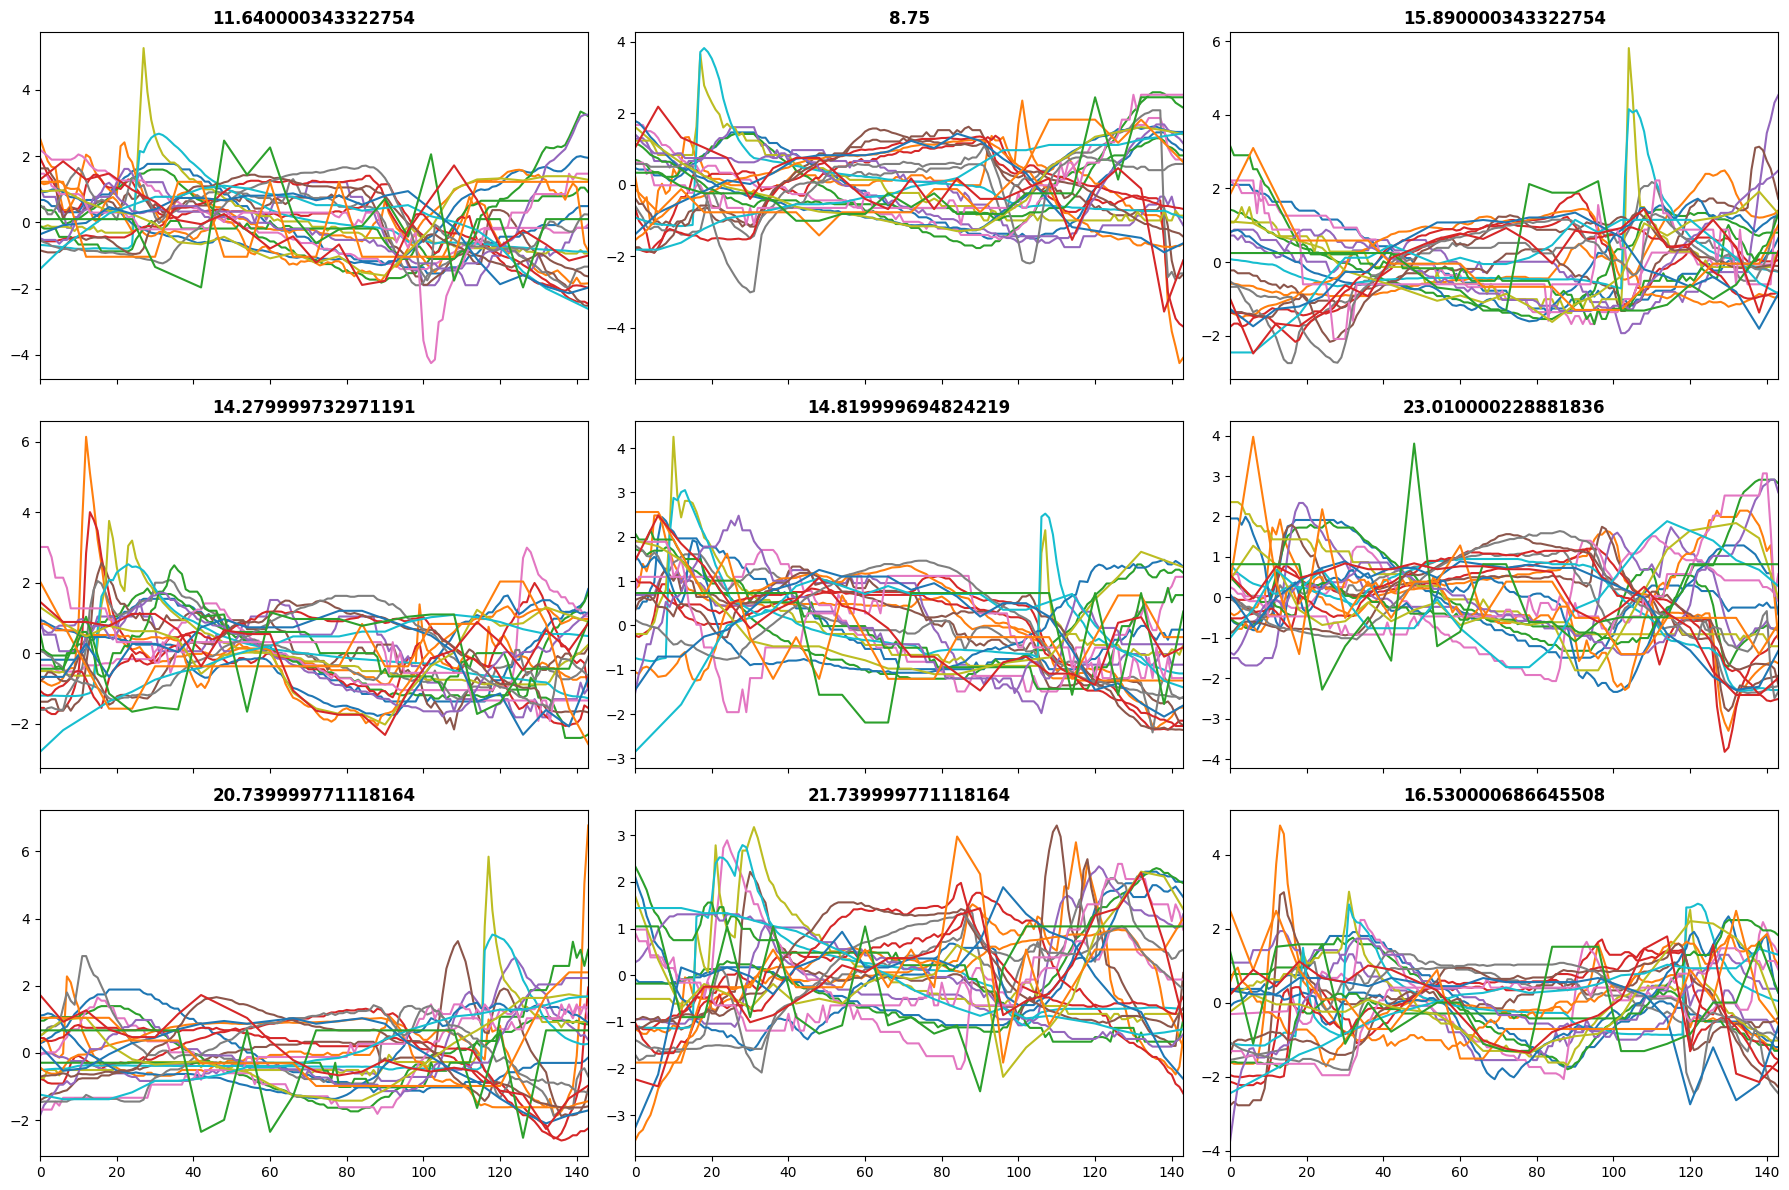

In [78]:
##### TUTORIAL #####
dls.show_batch()

In order to find the right learning rate for the ML model, we employ fastai's learner. 
They have a ts_learner (time series learner) that can run for 50 epochs with different metrics
to find the learning rate for the specific model. 
The learning rate is found by analysing the graph. The point with the fastest decrease in loss
is the highest learning rate. This value must be used in learn.fit_one_cycle()

[1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 2, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 2, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

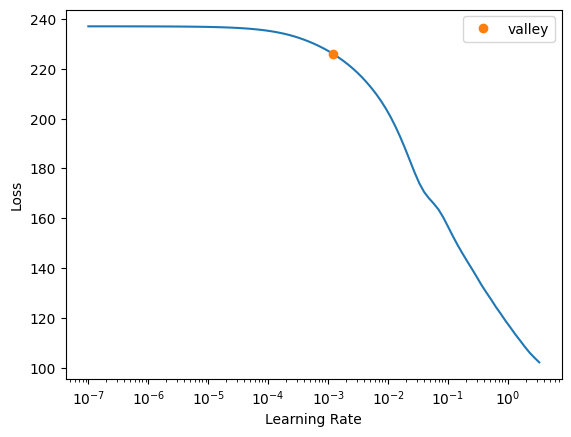

In [79]:
chosen_model = InceptionTime
learn = ts_learner(dls, chosen_model, metrics=[mae, rmse], cbs=ShowGraph())
lr_finder = learn.lr_find()

In [80]:
lrs = learn.recorder.lrs
losses = learn.recorder.losses
sma = 20
derivatives = [0]*(sma+1)

for i in range(1+sma, len(lrs)):
    d = (losses[i] - losses[i-sma]) / sma
    derivatives.append(d)

derivatives = np.array(derivatives)

best_idx = derivatives.argmin()
best_lr = lrs[best_idx]

print("Best LR:", best_lr)

Best LR: 0.36307805477010097


epoch,train_loss,valid_loss,mae,_rmse,time
0,216.420914,170.397873,12.589716,13.053654,00:01
1,196.345093,5489557.500000,2221.187012,2342.980469,00:02
2,172.140411,334291776.000000,17909.988281,18283.648438,00:02
3,142.525818,329860256.000000,17737.554688,18162.054688,00:01
4,115.377777,3273176832.000000,56421.667969,57211.683594,00:01
5,109.060684,3137474048.000000,55377.566406,56013.160156,00:01
6,100.957832,1590137344.000000,39362.207031,39876.527344,00:01
7,88.939857,747283840.000000,26716.583984,27336.492188,00:01
8,79.801598,78801136.000000,8657.203125,8877.000000,00:01
9,73.017601,6055973.500000,2396.524170,2460.888672,00:01


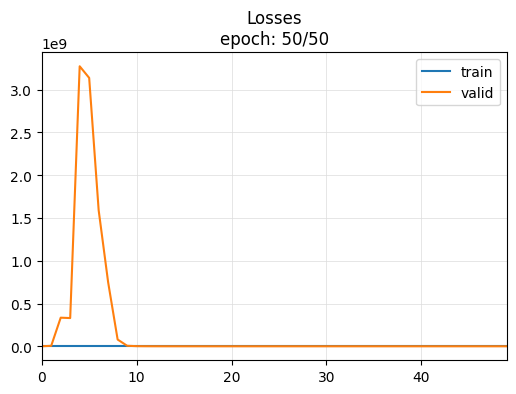

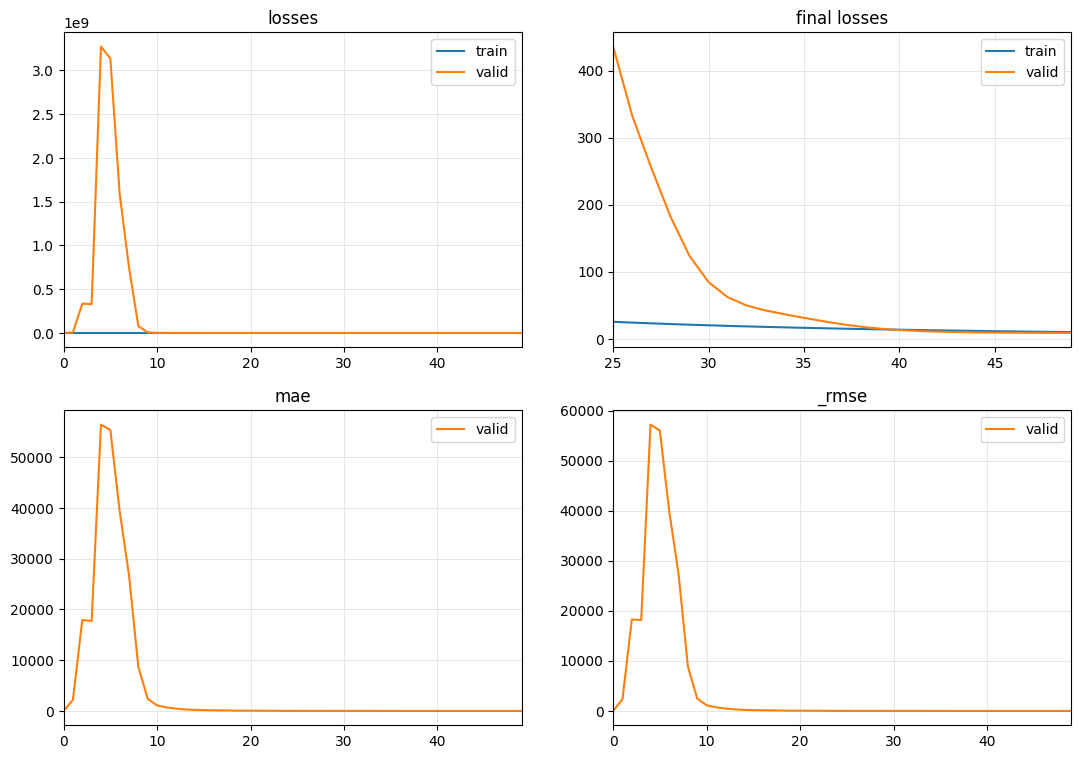

In [84]:
#### TUTORIAL ####
learn = ts_learner(dls, InceptionTime, metrics=[mae, rmse], cbs=ShowGraph())
learn.fit_one_cycle(50, best_lr)

We save the model in it's own path so that it can later be used on different test data for inferring. We need to know the RMSE and model name to evaluate the model on the test data.

In [85]:
val_loss, mae_val, rmse_val = learn.validate()

not enough values to plot a chart


In [90]:
PATH = Path(f"./models/regression_rmse{round(rmse_val,5)}_{str(chosen_model.__name__)}.pkl")
PATH.parent.mkdir(parents=True, exist_ok=True)
learn.export(PATH)

In [91]:
del learn